In [ ]:
## Day 9 - Random Forest Deep Dive

What I learned today:
- Feature importance tells you which columns the model relied on
- Fare, Sex, Age were the top 3 — matches real Titanic history
- Confusion matrix shows WHERE the model is wrong, not just how often
- 81% accuracy hides the fact that 19 survivors were predicted as dead

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
print("Rows, Columns:", df.shape)
df.head()
#print(df.isnull().sum())

Rows, Columns: (891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:

# Fill missing Age with average age
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill missing Embarked with most common value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin — 70% of it is empty, not useful
df = df.drop("Cabin", axis=1)

# Convert Sex: male → 0, female → 1
# ML only understands numbers, not words
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# Confirm no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [6]:
# X = inputs (what we know about each passenger)
# y = output (what we want to predict)

X = df[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]]
y = df["Survived"]

print("Input shape:", X.shape)
print("Output shape:", y.shape)
print()
print("Sample inputs:")
print(X.head())
print()
print("Sample outputs:")
print(y.head())

Input shape: (891, 6)
Output shape: (891,)

Sample inputs:
   Pclass  Sex   Age     Fare  SibSp  Parch
0       3    0  22.0   7.2500      1      0
1       1    1  38.0  71.2833      1      0
2       3    1  26.0   7.9250      0      0
3       1    1  35.0  53.1000      1      0
4       3    0  35.0   8.0500      0      0

Sample outputs:
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print("Training passengers:", len(X_train))
print("Testing passengers: ", len(X_test))

Training passengers: 712
Testing passengers:  179


In [8]:
# Create the model
model = RandomForestClassifier(random_state=42)

# Train it — this is where the learning happens
model.fit(X_train, y_train)

print("Model trained!")

# Test it on the 179 hidden passengers
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

Model trained!
Accuracy: 81.01%


  Feature  Importance
3    Fare    0.301807
1     Sex    0.272250
2     Age    0.257870
0  Pclass    0.080293
4   SibSp    0.052021
5   Parch    0.035759



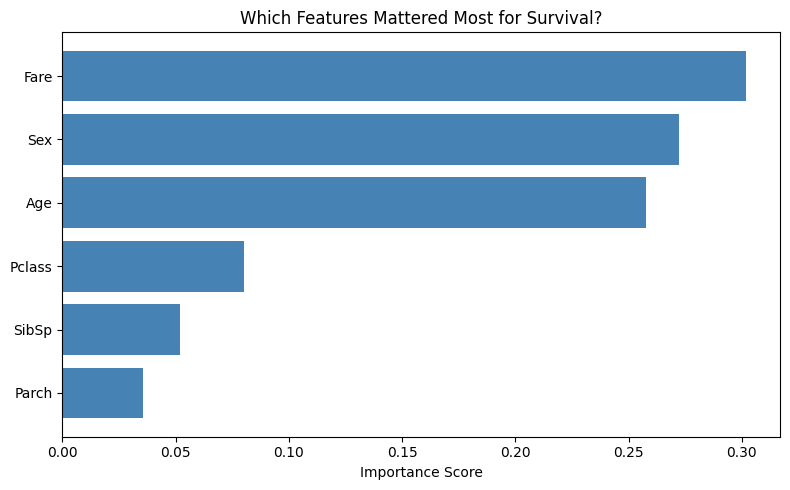

In [9]:
# Get importance scores for each feature
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df)
print()

# Plot it
plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Which Features Mattered Most for Survival?")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix
cm = confusion_matrix(y_test, predictions)

print("Confusion Matrix:")
print(cm)
print()
print("        Predicted NO  Predicted YES")
print(f"Actual NO      {cm[0][0]}           {cm[0][1]}")
print(f"Actual YES     {cm[1][0]}           {cm[1][1]}")

Confusion Matrix:
[[90 15]
 [19 55]]

        Predicted NO  Predicted YES
Actual NO      90           15
Actual YES     19           55
